In [156]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


**For Persian language processing in Python**

In [ ]:
!pip install hazm

In [ ]:
# hazm
from hazm import *


# Matplot
import matplotlib.pyplot as plt
%matplotlib inline

# DataFrame
import pandas as pd


# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


# Keras
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Activation, Dense, Dropout, Embedding, Flatten , MaxPooling1D, LSTM, SpatialDropout1D,GlobalMaxPool1D,Bidirectional
from keras import utils
from keras.callbacks import ReduceLROnPlateau, EarlyStopping , ModelCheckpoint
from keras.models import load_model


# Word2vec
import gensim



# Utility
import re
import numpy as np
import time
import pickle
import itertools

**Configs**

In [ ]:
# DATASET
DATASET_COLUMNS = ['target','text','rate','cat','type','product_id']
DATASET_ENCODING = "UTF-8"
TRAIN_SIZE = 0.8

# TEXT CLENAING
TEXT_CLEANING_RE = r"[^آ-ی]"

# WORD2VEC 
W2V_SIZE = 100
W2V_WINDOW = 5
W2V_EPOCH = 32
W2V_MIN_COUNT = 1

# KERAS
SEQUENCE_LENGTH = 100 # for padding
EPOCHS = 100
BATCH_SIZE = 1000

#pre_train model fasttext wikipedia
fasttext_model_pretrain = False

#if use save model set to True
use_save_model = True

**Load Dataset**

In [ ]:
df = pd.read_csv("/content/drive/My Drive/comment.csv",encoding =DATASET_ENCODING, names=DATASET_COLUMNS, header=0)

Convert integer target to 'POSITIVE' and 'NEGATIVE'

In [ ]:
decode_map = {1: "POSITIVE", 0: "NEGATIVE"}
def decode_sentiment(label):
    return decode_map[int(label)]
  
df.target = df.target.apply(lambda x: decode_sentiment(x))

In [ ]:
#shuffeling
df = df.sample(frac=1).reset_index(drop=True)

In [ ]:
df.tail(20)

,target,text,rate,cat,type,product_id
23028,NEGATIVE,کاملا بی کیفیت .مثل اسباب بازیه,0.615000,برس ها و تجهیزات آرایشی صورت,ست برس آرایشی مدل NAKED3 مجموعه 12 عددی,645628.0
23029,NEGATIVE,خیلی بی کیفیت هست اصلا ارزش خرید نداره,0.482600,ابزار آشپزی,گردوشکن سروش مدل سه کاره,407383.0
23030,POSITIVE,خیلی خوبه,0.550000,نوار بهداشتی,نوار بهداشتی نانسی مدل Air Laid بسته 10 عددی,1049661.0
23031,NEGATIVE,بدنه خیلی خشک و زود شکست قسمت حلویی هم خیلی زو...,0.619000,کیف و کاور گوشی,کیف کلاسوری نیلکین مدل Sparkle مناسب برای گوشی...,371297.0
23032,POSITIVE,هیچ مشکلی نداره و با همه دستگاه‌ها سازگاره خیل...,0.611000,کابل صوتی و تصویری,کابل HDMI دی-نت به طول 1.5 متر,130638.0
23033,POSITIVE,حرف نداره و از فاریکش حتی بهتره,0.646000,بند ساعت و مچ‌ بند,بند مچ بند هوشمند شیائومی مدل Mi Band 2 Wave,748309.0
23034,POSITIVE,عالیه خیلی خوب کار داده تا اینجای کارحدود ۸_۹م...,0.699000,پاوربانک (شارژر همراه),شارژر همراه انرجایزر مدل UE10004 با ظرفیت 1000...,190088.0
23035,POSITIVE,در کل مکعب خوبیه ولی اگه تازه وارد هستی بهتون ...,0.760000,بازی فکری,روبیک کیو آی وای آی مدل Qizheng s158 همراه با...,647616.0
23036,POSITIVE,یه خنکی مطلوبی یعد از استفاده روی پوست داره,0.728750,پاک کننده آرایش صورت,اسکراب روزانه کلین اند کلیر مدل Blackhead Clea...,207991.0
23037,NEGATIVE,در خرید این محصول تردید داشتم. اما وقتی به دست...,0.566500,برس ها و تجهیزات آرایشی صورت,استند لوازم آرایشی مدل cosmetic به همراه جا بر...,967690.0


In [ ]:
df

,target,text,rate,cat,type,product_id
0,POSITIVE,من استفاده کردم فقط با دو بار استفاده اثر خودش...,0.679500,رول ضد تعریق,ضد تعریق درایسول مدل Extra Strength حجم 35 میل...,797926.0
1,POSITIVE,یه مقدار خش افتاده رو تخته,0.700000,تخته وایت‌برد و کلیربرد,تخته وایت برد مغناطیسی شیدکو سایز 90x120,494218.0
2,POSITIVE,من حدود ده روزه این ماشین لباسشویی رو از دیجی ...,0.883333,ماشین لباسشویی,ماشین لباسشویی ال جی مدل WM-527 ظرفیت 7 کیلوگرم,146877.0
3,POSITIVE,خیلی خوبه من تو پیشنهاد ویژه خریدم می‌ارزه,0.689000,پاوربانک (شارژر همراه),شارژر همراه لپو مدل P15 5000,73792.0
4,POSITIVE,عالی در یک کلمه,0.753250,خمیر دندان,خمیر دندان سفید کننده سنسوداین مدل Repair And ...,423154.0
...,...,...,...,...,...,...
23043,NEGATIVE,سلام,0.691750,مچ بند هوشمند,مچ بند هوشمند آی واون مدل i6 HR,225042.0
23044,POSITIVE,بنظرم که خوبه نسبتا کیفیت مناسبی داره و قیمتش ...,0.800000,پیچ گوشتی و فازمتر,مجموعه 33 عددی پیچ گوشتی آروا,485002.0
23045,POSITIVE,واقعا فوق العادس خریدشو به همه پیشنهاد میکنم،م...,0.807800,کیف و کاور لپ تاپ,کیف لپ تاپ پیر گاردین مدل 505 مناسب برای لپ ت...,543596.0
23046,NEGATIVE,هیچ امکانات خوبی نداره پشیمونم ازخریدم,0.648000,دوربین عکاسی,دوربین دیجیتال سامسونگ مدل ES95,25946.0


**example for matplotlib**

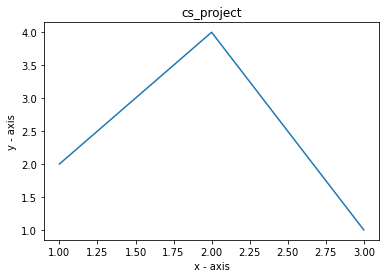

In [ ]:
# importing the required module 
import matplotlib.pyplot as plt 
  
# x axis values 
x = [1,2,3] 
# corresponding y axis values 
y = [2,4,1] 
  
# plotting the points  
plt.plot(x, y) 
  
# naming the x axis 
plt.xlabel('x - axis') 
# naming the y axis 
plt.ylabel('y - axis') 
  
# giving a title to my graph 
plt.title('cs_project') 
  
# function to show the plot 
plt.show()

**plot distribute of targets**

/usr/local/lib/python3.6/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


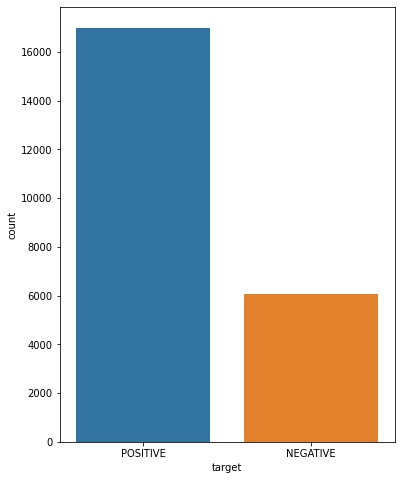

In [ ]:
import seaborn as sns
plt.figure(figsize = (6, 8))
sns.countplot(df['target'])
plt.show()

**text pre_processing**

In [ ]:
import io

# read stopwords list
stopwords = []
filepath = "/content/drive/My Drive/stopwords.txt"
with open(filepath, 'r') as f:
    for line in f:
      stopwords.append(line.strip())

**stop words and normalizer**

In [ ]:
normalizer = Normalizer()
stemmer = Stemmer()
def preprocess(text, stem=False):
    text = text.replace('.', ' ')
    text = text.replace('ي', 'ی').replace('ك', 'ک')
    text = text.replace("-","")
    text = text.replace('(', ' ')
    text = text.replace(')', ' ')
    text = text.replace("«"," ")
    text = text.replace("»"," ")
    text = normalizer.normalize(text)
    text = re.sub(TEXT_CLEANING_RE, ' ', str(text)).strip() # remove all character except farsi character
    
    tokens = []
    # for token in text.split():
    for token in word_tokenize(text):
        if token not in stopwords:
            if stem:
                tokens.append(stemmer.stem(token))
            else:
                tokens.append(token)
    return " ".join(tokens)

In [ ]:
df.text = df.text.apply(lambda x: preprocess(x))

In [ ]:
df.tail(20)

,target,text,rate,cat,type,product_id
23028,NEGATIVE,کیفیت مثل اسباب بازیه,0.615000,برس ها و تجهیزات آرایشی صورت,ست برس آرایشی مدل NAKED3 مجموعه 12 عددی,645628.0
23029,NEGATIVE,کیفیت هست اصلا ارزش خرید نداره,0.482600,ابزار آشپزی,گردوشکن سروش مدل سه کاره,407383.0
23030,POSITIVE,خوبه,0.550000,نوار بهداشتی,نوار بهداشتی نانسی مدل Air Laid بسته 10 عددی,1049661.0
23031,NEGATIVE,بدنه خشک زود شکست قسمت حلویی زود بغلها وا رفت,0.619000,کیف و کاور گوشی,کیف کلاسوری نیلکین مدل Sparkle مناسب برای گوشی...,371297.0
23032,POSITIVE,هیچ مشکلی نداره دستگاه ها سازگاره خوبه عاشق دی...,0.611000,کابل صوتی و تصویری,کابل HDMI دی-نت به طول 1.5 متر,130638.0
23033,POSITIVE,حرف نداره فاریکش بهتره,0.646000,بند ساعت و مچ‌ بند,بند مچ بند هوشمند شیائومی مدل Mi Band 2 Wave,748309.0
23034,POSITIVE,عالیه خوب کار اینجای کارحدود ماهی هست دارمش از...,0.699000,پاوربانک (شارژر همراه),شارژر همراه انرجایزر مدل UE10004 با ظرفیت 1000...,190088.0
23035,POSITIVE,مکعب خوبیه اگه تازه وارد هستی بهتون پیشنهاد می...,0.760000,بازی فکری,روبیک کیو آی وای آی مدل Qizheng s158 همراه با...,647616.0
23036,POSITIVE,یه خنکی مطلوبی یعد استفاده پوست داره,0.728750,پاک کننده آرایش صورت,اسکراب روزانه کلین اند کلیر مدل Blackhead Clea...,207991.0
23037,NEGATIVE,خرید محصول تردید داشتم دستم رسید دیدم پایه آین...,0.566500,برس ها و تجهیزات آرایشی صورت,استند لوازم آرایشی مدل cosmetic به همراه جا بر...,967690.0


**split train test**

In [ ]:
df_train, df_test = train_test_split(df, test_size=1-TRAIN_SIZE, random_state=42)
print("TRAIN size:", len(df_train))
print("TEST size:", len(df_test))

TRAIN size: 18438
TEST size: 4610


In [ ]:
word_tokenize("محمد و فواد درس پروژه کارشناسی دارند")

['محمد', 'و', 'فواد', 'درس', 'پروژه', 'کارشناسی', 'دارند']

In [ ]:
df

,target,text,rate,cat,type,product_id
0,POSITIVE,استفاده کردم دو بار استفاده اثر رو گذاشته الان...,0.679500,رول ضد تعریق,ضد تعریق درایسول مدل Extra Strength حجم 35 میل...,797926.0
1,POSITIVE,یه مقدار خش افتاده رو تخته,0.700000,تخته وایت‌برد و کلیربرد,تخته وایت برد مغناطیسی شیدکو سایز 90x120,494218.0
2,POSITIVE,حدود ده روزه ماشین لباسشویی رو دیجی خریدم,0.883333,ماشین لباسشویی,ماشین لباسشویی ال جی مدل WM-527 ظرفیت 7 کیلوگرم,146877.0
3,POSITIVE,خوبه پیشنهاد خریدم می ارزه,0.689000,پاوربانک (شارژر همراه),شارژر همراه لپو مدل P15 5000,73792.0
4,POSITIVE,عالی کلمه,0.753250,خمیر دندان,خمیر دندان سفید کننده سنسوداین مدل Repair And ...,423154.0
...,...,...,...,...,...,...
23043,NEGATIVE,سلام,0.691750,مچ بند هوشمند,مچ بند هوشمند آی واون مدل i6 HR,225042.0
23044,POSITIVE,بنظرم خوبه نسبتا کیفیت مناسبی داره قیمتش توجه ...,0.800000,پیچ گوشتی و فازمتر,مجموعه 33 عددی پیچ گوشتی آروا,485002.0
23045,POSITIVE,واقعا فوق العادس خریدشو پیشنهاد میکنم ممنون دی...,0.807800,کیف و کاور لپ تاپ,کیف لپ تاپ پیر گاردین مدل 505 مناسب برای لپ ت...,543596.0
23046,NEGATIVE,هیچ امکانات خوبی نداره پشیمونم ازخریدم,0.648000,دوربین عکاسی,دوربین دیجیتال سامسونگ مدل ES95,25946.0


**convert dataset to document , use for Word2vec embedding**

In [ ]:
documents = [_text.split() for _text in df_train.text]

In [ ]:
print(documents[1])

['عالی', 'هستش', 'الان', 'دستم', 'رسید']


**Create w2v model**

In [ ]:
w2v_model = gensim.models.Word2Vec(size=W2V_SIZE, 
                                   window=W2V_WINDOW, 
                                   min_count=W2V_MIN_COUNT)

In [ ]:
w2v_model.build_vocab(documents)

**keras Tokenizer for get dictionary of words and count of words**

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df_train.text)

vocab_size = len(tokenizer.word_index) + 1
print("Total words", vocab_size)

Total words 18037


In [ ]:
 print(tokenizer.word_counts)

OrderedDict([('شدیدا', 26), ('بوی', 397), ('چسب', 133), ('میده', 558), ('پلاسیک', 1), ('داخلش', 112), ('رو', 5140), ('باچسب', 1), ('سطل', 12), ('چسبوندن', 9), ('اصلا', 1767), ('جنس', 779), ('تمیز', 191), ('وبا', 21), ('کیفیتی', 100), ('قیمت', 1703), ('عالی', 1930), ('هستش', 511), ('الان', 605), ('دستم', 770), ('رسید', 736), ('داره', 3632), ('خریدم', 2584), ('دو', 929), ('چرخوندم', 2), ('اونم', 129), ('آروم', 10), ('پیچش', 9), ('پوسیده', 5), ('چی', 117), ('کنده', 65), ('شد', 827), ('درواقع', 6), ('پولمو', 20), ('ریختم', 55), ('انصافا', 32), ('راضی', 1518), ('بودم', 599), ('کیفیت', 2844), ('خوبی', 1651), ('نمیدونم', 152), ('صدای', 340), ('خش', 106), ('خشش', 2), ('هست', 2649), ('مال', 44), ('خرابه', 36), ('نویزش', 2), ('معلومه', 23), ('آزار', 19), ('دهندست', 2), ('توی', 701), ('شگفت', 594), ('انگیز', 559), ('بچه', 118), ('ها', 993), ('خوششون', 12), ('اومد', 153), ('طعمش', 18), ('دوست', 174), ('داشتن', 96), ('خوبه', 2118), ('راضیم', 862), ('فوق', 578), ('العادست', 46), ('حتما', 792), ('بخر

**Example of tokenizer and pad_sequences**

In [ ]:
s = tokenizer.texts_to_sequences([df_train.text[1]])
print(s)
print(tokenizer.sequences_to_texts(s))
print(df_train.text[1])
s_pad = pad_sequences(s,padding='post' ,maxlen=SEQUENCE_LENGTH)
print(s_pad)

[[16, 329, 471, 1229, 1, 3536]]
['یه مقدار خش افتاده رو تخته']
یه مقدار خش افتاده رو تخته
[[  16  329  471 1229    1 3536    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0]]


**set padding for sentence vector to fix vector size**

In [ ]:
x_train = pad_sequences(tokenizer.texts_to_sequences(df_train.text),padding='post', maxlen=SEQUENCE_LENGTH)
x_test = pad_sequences(tokenizer.texts_to_sequences(df_test.text),padding='post', maxlen=SEQUENCE_LENGTH)

In [ ]:
df_train.head(2)

,target,text,rate,cat,type,product_id
3728,NEGATIVE,شدیدا بوی چسب میده پلاسیک داخلش رو باچسب سطل چ...,0.7018,ظرف برنج,سطل برنج استیل پیمانه دار آرتیستون مدل 008 گن...,452119.0
15286,POSITIVE,عالی هستش الان دستم رسید,0.8045,کفش زنانه,نیم بوت زنانه نهرین مدل سیندرلا 200,768638.0


In [ ]:
print(x_train[0])

[1441  122  370   79 9435  450    1 9436 2404 2892   18   54  250 1683
  500   19    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]


**labels**

In [ ]:
labels = df_train.target.unique().tolist()
print(labels)


['NEGATIVE', 'POSITIVE']


**Encoder for lables**

In [ ]:
encoder = LabelEncoder()
encoder.fit(df_train.target.tolist())

y_train = encoder.transform(df_train.target.tolist())
y_test = encoder.transform(df_test.target.tolist())

y_train = pd.get_dummies(y_train).values
y_test = pd.get_dummies(y_test).values

# print("y_train",y_train.shape)
# print("y_test",y_test.shape)
 

print(y_train[0])
print(x_train[0])

print(y_train[11])
print(y_test[6])

[1 0]
[1441  122  370   79 9435  450    1 9436 2404 2892   18   54  250 1683
  500   19    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]
[0 1]
[0 1]


In [ ]:
df_train.head(20)

,target,text,rate,cat,type,product_id
3728,NEGATIVE,شدیدا بوی چسب میده پلاسیک داخلش رو باچسب سطل چ...,0.701800,ظرف برنج,سطل برنج استیل پیمانه دار آرتیستون مدل 008 گن...,452119.0
15286,POSITIVE,عالی هستش الان دستم رسید,0.804500,کفش زنانه,نیم بوت زنانه نهرین مدل سیندرلا 200,768638.0
450,NEGATIVE,جنس کیفیتی داره خریدم دو چرخوندم اونم آروم پیچ...,0.290750,پایه نگهدارنده گوشی و تبلت,سه پایه نگهدارنده مدل LR-108,217019.0
14540,POSITIVE,انصافا خریدم راضی بودم,0.950000,شیشه شیر، سرلاک و داروخوری,شیشه شیر یومیی مدل N100001-T ظرفیت 160 میلی لیتر,169488.0
2066,POSITIVE,کیفیت خوبی داره نمیدونم صدای خش خشش هست مال خر...,0.728200,هدفون,هدفون وان مور مدل Piston Fit,197266.0
15185,POSITIVE,توی شگفت انگیز خریدم بچه ها خوششون اومد طعمش ر...,0.793000,تن ماهی,کنسرو ماهی تون در روغن گیاهی طبیعت مقدار 180 گرم,847467.0
1071,POSITIVE,راضی بودم,0.610800,کیف و کاور لپ تاپ,محافظ صفحه نمایش مدل Screen Guard مناسب برای ل...,765656.0
20393,POSITIVE,خوبه راضیم,0.780000,پایه نگهدارنده گوشی و تبلت,حلقه نگهدارنده گوشی موبایل مدلRing Hook کد Hy-18,621286.0
6750,POSITIVE,فوق العادست حتما بخرید دوستان,0.772000,هدفون,هدفون بلوتوثی زیلوت مدل B570,319832.0
16519,POSITIVE,توپو ماه خریدم الان راضیم روش استفادش برا ماشی...,0.846000,شوینده لباس,توپ رخت شویی نوترون,363271.0


**example for dummies**

In [ ]:
 s = pd.Series(list('abca'))
 pd.get_dummies(s)

,a,b,c
0,1,0,0
1,0,1,0
2,0,0,1
3,1,0,0


In [ ]:
print("x_train", x_train.shape)
print("y_train", y_train.shape)
print()
print("x_test", x_test.shape)
print("y_test", y_test.shape)

x_train (18438, 100)
y_train (18438, 2)

x_test (4610, 100)
y_test (4610, 2)


**build embedding matrix**

In [ ]:
embedding_matrix = np.zeros((vocab_size, W2V_SIZE))
unkwon_word_count = 0
uw = []
for word, i in tokenizer.word_index.items():
  if word in w2v_model.wv:
    embedding_matrix[i] = w2v_model.wv[word]
  else:
      uw.append(word)
      unkwon_word_count += 1
print(embedding_matrix.shape)
print(unkwon_word_count)

(18037, 100)
24


**create embedding layer**

In [ ]:
# use keras embedding with training
embedding_layer = Embedding(vocab_size, W2V_SIZE,input_length=SEQUENCE_LENGTH,trainable=True)

**Build model**

In [ ]:
model = Sequential()#provides training and inference features on this model.

model.add(embedding_layer)
model.add(Bidirectional(LSTM(32, return_sequences = True)))
model.add(GlobalMaxPool1D())
model.add(Dense(20, activation="relu"))
model.add(Dropout(0.05))
model.add(Dense(2, activation="softmax"))

# model.summary()

In [ ]:
model.compile(loss='categorical_crossentropy',optimizer="adam", metrics=['acc'])
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=15 )
callbacks = [es] # for earlystopping for avoiding overfitting

**fit model**

In [157]:
history = model.fit(x_train, y_train,
                    batch_size=BATCH_SIZE,
                    epochs=10,
                    validation_split=0.1,
                    verbose=1,
                    callbacks=callbacks)

Epoch 1/10
17/17 [==============================] - 17s 981ms/step - loss: 0.0369 - acc: 0.9889 - val_loss: 0.4542 - val_acc: 0.8932
Epoch 2/10
17/17 [==============================] - 17s 977ms/step - loss: 0.0349 - acc: 0.9893 - val_loss: 0.4721 - val_acc: 0.8937
Epoch 3/10
17/17 [==============================] - 17s 976ms/step - loss: 0.0320 - acc: 0.9903 - val_loss: 0.5163 - val_acc: 0.8910
Epoch 4/10
17/17 [==============================] - 17s 975ms/step - loss: 0.0308 - acc: 0.9904 - val_loss: 0.5214 - val_acc: 0.8926
Epoch 5/10
17/17 [==============================] - 17s 975ms/step - loss: 0.0291 - acc: 0.9910 - val_loss: 0.5333 - val_acc: 0.8921
Epoch 6/10
17/17 [==============================] - 17s 973ms/step - loss: 0.0273 - acc: 0.9913 - val_loss: 0.5562 - val_acc: 0.8894
Epoch 7/10
17/17 [==============================] - 17s 979ms/step - loss: 0.0264 - acc: 0.9918 - val_loss: 0.5675 - val_acc: 0.8910
Epoch 8/10
17/17 [==============================] - 17s 976ms/step - 

In [ ]:
# w = model.get_weights()
# w[0]


**train evaluation**

In [158]:
score = model.evaluate(x_train, y_train, batch_size=100)
print(score)
print()
print("Train ACCURACY:",score[1])
print("Train LOSS:",score[0])

185/185 [==============================] - 7s 35ms/step - loss: 0.0813 - acc: 0.9806
[0.08133900165557861, 0.9805835485458374]

Train ACCURACY: 0.9805835485458374
Train LOSS: 0.08133900165557861


**test evaluation**

In [159]:
score = model.evaluate(x_test, y_test, batch_size=100)
print(score)
print()
print("Test ACCURACY:",score[1])
print("Test LOSS:",score[0])

47/47 [==============================] - 2s 36ms/step - loss: 0.5876 - acc: 0.8792
[0.5875812768936157, 0.8791757225990295]

Test ACCURACY: 0.8791757225990295
Test LOSS: 0.5875812768936157


**confusion matrix plot**

4610/4610 - 28s
[[ 919  283]
 [ 274 3134]]


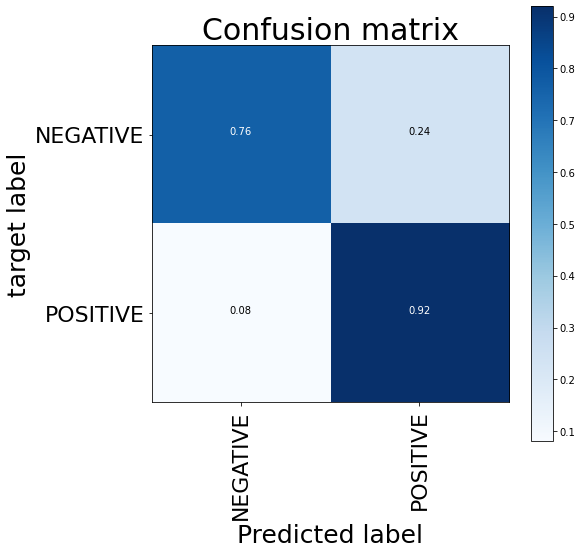

In [205]:
from sklearn.metrics import classification_report,confusion_matrix

y_pred = model.predict(x_test,batch_size=1,verbose=2)
y_test_class = np.argmax(y_test,axis=1)
y_pred_class = np.argmax(y_pred,axis=1)

# y_pred = model.predict(x_train,batch_size=1,verbose=2)
# y_train_class = np.argmax(y_train,axis=1)
# y_pred_class = np.argmax(y_pred,axis=1)

# print(classification_report(y_test_class,y_pred_class))
print(confusion_matrix(y_test_class,y_pred_class))

def plot_confusion_matrix(cm, classes,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """

    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=30)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90, fontsize=22)
    plt.yticks(tick_marks, classes, fontsize=22)

    fmt = '.2f'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('target label', fontsize=25)
    plt.xlabel('Predicted label', fontsize=25)

    
cnf_matrix = confusion_matrix(y_test_class, y_pred_class)
plt.figure(figsize=(8,8))
plot_confusion_matrix(cnf_matrix, classes=df_train.target.unique(), title="Confusion matrix")
plt.show()


**predict one sentence**

In [206]:
def predict(text, include_neutral=True):
    start_at = time.time()
    # Tokenize text
    x_test = pad_sequences(tokenizer.texts_to_sequences([text]), maxlen=SEQUENCE_LENGTH)
    # Predict
    score = model.predict([x_test])[0]
    return score


In [207]:
sense_dic = {0:"negative", 1:"positive"}

In [208]:
text = "بوی بدی میده"
res = predict(text)
print(res)
sense_dic[np.argmax(res)]


[0.70486325 0.29513672]


'negative'

In [209]:
text = "خیلی خوبه این گوشی "
res = predict(text)
print(res)
sense_dic[np.argmax(res)]

[0.1324675 0.8675325]


'positive'

In [212]:
user_test = input("Text : ")
while user_test != "":
  res = predict(user_test)
  print(res)
  print(sense_dic[np.argmax(res)])
  print('------------------')
  user_test = input("Text : ")

Text : 
